# Part 3

### A. Returns in USD

In [419]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Preliminaries : setting the data

In [420]:
# Create dataframe with conversion rate
aud_to_usd = pd.read_csv('./data/EXUSAL.csv') # aud to usd
eur_to_usd = pd.read_csv('./data/EXUSEU.csv') # eur to usd
jpy_to_usd = pd.read_csv('./data/EXJPUS.csv') # usd to jpy
chf_to_usd = pd.read_csv('./data/EXSZUS.csv') # usd to chf
gbp_to_usd = pd.read_csv('./data/EXUSUK.csv') # gbp to usd

aud_to_usd = aud_to_usd.rename(columns={'EXUSAL': 'exchange_rate'})
eur_to_usd = eur_to_usd.rename(columns={'EXUSEU': 'exchange_rate'})
jpy_to_usd = jpy_to_usd.rename(columns={'EXJPUS': 'exchange_rate'})
chf_to_usd = chf_to_usd.rename(columns={'EXSZUS': 'exchange_rate'})
gbp_to_usd = gbp_to_usd.rename(columns={'EXUSUK': 'exchange_rate'})

In [421]:
# handle NaN values
aud_to_usd['exchange_rate'] = aud_to_usd['exchange_rate'].interpolate(method='linear') 
eur_to_usd['exchange_rate'] = eur_to_usd['exchange_rate'].interpolate(method='linear')
jpy_to_usd['exchange_rate'] = 1/jpy_to_usd['exchange_rate'].interpolate(method='linear')
chf_to_usd['exchange_rate'] = 1/chf_to_usd['exchange_rate'].interpolate(method='linear')
gbp_to_usd['exchange_rate'] = gbp_to_usd['exchange_rate'].interpolate(method='linear')

In [422]:
#transform these exchange rates into FX returns 
aud_to_usd['FX_return'] = (aud_to_usd['exchange_rate'] - aud_to_usd['exchange_rate'].shift(1)) / aud_to_usd['exchange_rate'].shift(1)
eur_to_usd['FX_return'] = (eur_to_usd['exchange_rate'] - eur_to_usd['exchange_rate'].shift(1)) / eur_to_usd['exchange_rate'].shift(1)
jpy_to_usd['FX_return'] = (jpy_to_usd['exchange_rate'] - jpy_to_usd['exchange_rate'].shift(1)) / jpy_to_usd['exchange_rate'].shift(1)
chf_to_usd['FX_return'] = (chf_to_usd['exchange_rate'] - chf_to_usd['exchange_rate'].shift(1)) / chf_to_usd['exchange_rate'].shift(1)
gbp_to_usd['FX_return'] = (gbp_to_usd['exchange_rate'] - gbp_to_usd['exchange_rate'].shift(1)) / gbp_to_usd['exchange_rate'].shift(1)


In [423]:
#drop NaN
aud_to_usd = aud_to_usd.dropna()
eur_to_usd = eur_to_usd.dropna()
jpy_to_usd = jpy_to_usd.dropna()
chf_to_usd = chf_to_usd.dropna()
gbp_to_usd = gbp_to_usd.dropna()

aud_to_usd

,observation_date,exchange_rate,FX_return
1,2002-02-01,0.5128,-0.008124
2,2002-03-01,0.5256,0.024961
3,2002-04-01,0.5352,0.018265
4,2002-05-01,0.5498,0.027280
5,2002-06-01,0.5682,0.033467
...,...,...,...
271,2024-08-01,0.6658,-0.002248
272,2024-09-01,0.6770,0.016822
273,2024-10-01,0.6700,-0.010340
274,2024-11-01,0.6528,-0.025672


In [424]:
# Load the stocks per country
world_data = pd.read_csv('./data/country_data.csv', sep=';')

australia = world_data[world_data.country == 'AUSTRALIA'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
france = world_data[world_data.country == 'FRANCE'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
germany = world_data[world_data.country == 'GERMANY'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
japan = world_data[world_data.country == 'JAPAN'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
switzerland = world_data[world_data.country == 'SWITZERLAND'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
britain = world_data[world_data.country == 'UNITED KINGDOM'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})

# Load the stocks for the US
usa = pd.read_csv('./data/crsp_value_weighted_returns.csv', sep=';').rename(columns={'vwretx': 'monthly_price_return', 'vwretd': 'monthly_total_return'})

In [425]:
# adjust dates
aud_to_usd['observation_date'] = (pd.to_datetime(aud_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
eur_to_usd['observation_date'] = (pd.to_datetime(eur_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
jpy_to_usd['observation_date'] = (pd.to_datetime(jpy_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
chf_to_usd['observation_date'] = (pd.to_datetime(chf_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
gbp_to_usd['observation_date'] = (pd.to_datetime(gbp_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')

australia['date'] = pd.to_datetime(australia['date']).dt.strftime('%Y-%m')
france['date'] = pd.to_datetime(france['date']).dt.strftime('%Y-%m')
japan['date'] = pd.to_datetime(japan['date']).dt.strftime('%Y-%m')
germany['date'] = pd.to_datetime(germany['date']).dt.strftime('%Y-%m')
switzerland['date'] = pd.to_datetime(switzerland['date']).dt.strftime('%Y-%m')
usa['date'] = pd.to_datetime(usa['date']).dt.strftime('%Y-%m')
britain['date'] = pd.to_datetime(britain['date']).dt.strftime('%Y-%m')

In [426]:
# Compute returns in USD
australia = australia.iloc[3:].merge(aud_to_usd, left_on='date', right_on='observation_date')
australia['monthly_total_return_USD'] = (1+australia['monthly_total_return'])*(1+australia['FX_return'])-1
australia['monthly_price_return_USD'] = (1+australia['monthly_price_return'])*(1+australia['FX_return'])-1
australia = australia.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

france = france.iloc[3:].merge(eur_to_usd, left_on='date', right_on='observation_date')
france['monthly_total_return_USD'] = (1+france['monthly_total_return'])*(1+france['FX_return'])-1
france['monthly_price_return_USD'] = (1+france['monthly_price_return'])*(1+france['FX_return'])-1
france = france.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

germany = germany.iloc[3:].merge(eur_to_usd, left_on='date', right_on='observation_date')
germany['monthly_total_return_USD'] = (1+germany['monthly_total_return'])*(1+germany['FX_return'])-1
germany['monthly_price_return_USD'] = (1+germany['monthly_price_return'])*(1+germany['FX_return'])-1
germany = germany.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

japan = japan.merge(jpy_to_usd, left_on='date', right_on='observation_date')
japan['monthly_total_return_USD'] = (1+japan['monthly_total_return'])*(1+japan['FX_return'])-1
japan['monthly_price_return_USD'] = (1+japan['monthly_price_return'])*(1+japan['FX_return'])-1
japan = japan.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

switzerland = switzerland.iloc[3:].merge(chf_to_usd, left_on='date', right_on='observation_date')
switzerland['monthly_total_return_USD'] = (1+switzerland['monthly_total_return'])*(1+switzerland['FX_return'])-1
switzerland['monthly_price_return_USD'] = (1+switzerland['monthly_price_return'])*(1+switzerland['FX_return'])-1
switzerland = switzerland.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

britain = britain.iloc[3:].merge(gbp_to_usd, left_on='date', right_on='observation_date')
britain['monthly_total_return_USD'] = (1+britain['monthly_total_return'])*(1+britain['FX_return'])-1
britain['monthly_price_return_USD'] = (1+britain['monthly_price_return'])*(1+britain['FX_return'])-1
britain = britain.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

usa = usa.iloc[3:-1].reset_index(drop=True)
usa

,date,monthly_price_return,monthly_total_return
0,2002-04,-0.050504,-0.049600
1,2002-05,-0.011958,-0.010510
2,2002-06,-0.071515,-0.070259
3,2002-07,-0.082310,-0.081125
4,2002-08,0.006405,0.007949
...,...,...,...
267,2024-07,0.019000,0.019878
268,2024-08,0.020203,0.021572
269,2024-09,0.019485,0.020969
270,2024-10,-0.009139,-0.008298


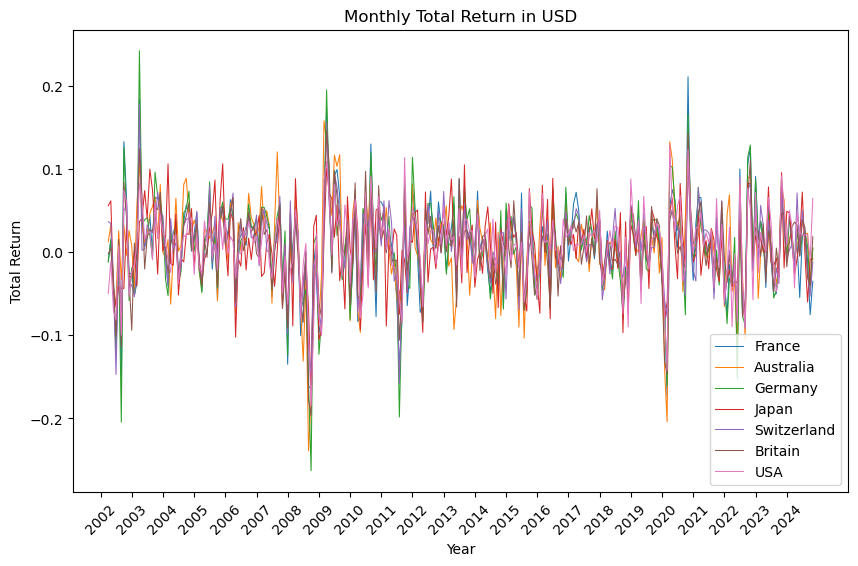

In [427]:
import matplotlib.dates as mdates

france['date'] = pd.to_datetime(france['date'])
australia['date'] = pd.to_datetime(australia['date'])
germany['date'] = pd.to_datetime(germany['date'])
japan['date'] = pd.to_datetime(japan['date'])
switzerland['date'] = pd.to_datetime(switzerland['date'])
britain['date'] = pd.to_datetime(britain['date'])
usa['date'] = pd.to_datetime(usa['date']) 

plt.figure(figsize=(10,6))
plt.plot(france['date'], france['monthly_total_return_USD'], label='France', linestyle='-', linewidth=0.75)
plt.plot(australia['date'], australia['monthly_total_return_USD'], label='Australia', linestyle='-', linewidth=0.75)
plt.plot(germany['date'], germany['monthly_total_return_USD'], label='Germany', linestyle='-', linewidth=0.75)
plt.plot(japan['date'], japan['monthly_total_return_USD'], label='Japan', linestyle='-', linewidth=0.75)
plt.plot(switzerland['date'], switzerland['monthly_total_return_USD'], label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(britain['date'], britain['monthly_total_return_USD'], label='Britain', linestyle='-', linewidth=0.75)
plt.plot(usa['date'], usa['monthly_total_return'], label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Total Return')
plt.show()


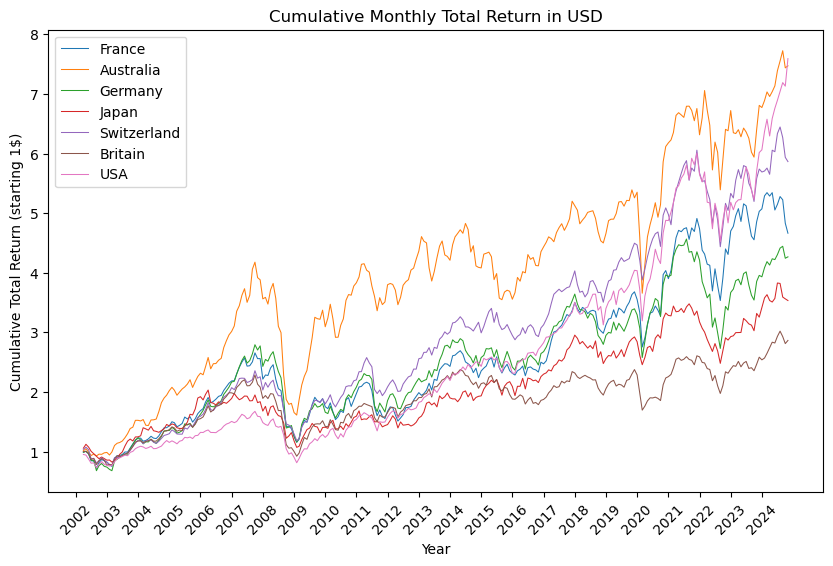

In [428]:
plt.figure(figsize=(10,6))
plt.plot(france['date'], (1 + france['monthly_total_return_USD']).cumprod(), label='France', linestyle='-', linewidth=0.75)
plt.plot(australia['date'], (1 + australia['monthly_total_return_USD']).cumprod(), label='Australia', linestyle='-', linewidth=0.75)
plt.plot(germany['date'], (1 + germany['monthly_total_return_USD']).cumprod(), label='Germany', linestyle='-', linewidth=0.75)
plt.plot(japan['date'], (1 + japan['monthly_total_return_USD']).cumprod(), label='Japan', linestyle='-', linewidth=0.75)
plt.plot(switzerland['date'], (1 + switzerland['monthly_total_return_USD']).cumprod(), label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(britain['date'], (1 + britain['monthly_total_return_USD']).cumprod(), label='Britain', linestyle='-', linewidth=0.75)
plt.plot(usa['date'], (1 + usa['monthly_total_return']).cumprod(), label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Cumulative Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Cumulative Total Return (starting 1$)')
plt.show()

In [429]:
df = pd.DataFrame({
    'date': usa['date'].dt.strftime('%m-%Y'),
    'France': france['monthly_total_return_USD'],
    'Australia': australia['monthly_total_return_USD'],
    'Germany': germany['monthly_total_return_USD'],
    'Japan': japan['monthly_total_return_USD'],
    'Switzerland': switzerland['monthly_total_return_USD'],
    'Britain': britain['monthly_total_return_USD'],
    'USA': usa['monthly_total_return']
})

df.to_csv('./data/USD_monthly_returns.csv', index=False)

df

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,05-2002,0.013428,0.033256,0.015840,0.061906,0.034877,0.004702,-0.010510
2,06-2002,-0.044850,-0.051421,-0.032251,-0.041866,-0.039197,-0.037508,-0.070259
3,07-2002,-0.117957,-0.059533,-0.122706,-0.066380,-0.147091,-0.101053,-0.081125
4,08-2002,-0.002077,0.025970,-0.000348,-0.041213,0.007842,0.015599,0.007949
...,...,...,...,...,...,...,...,...
267,07-2024,0.018647,0.035730,0.019748,0.072474,0.050481,0.039456,0.019878
268,08-2024,0.025529,0.021983,0.025336,-0.001815,0.017400,0.029770,0.021572
269,09-2024,-0.010247,0.022941,0.007013,-0.059865,-0.027682,-0.030240,0.020969
270,10-2024,-0.075214,-0.037250,-0.045202,-0.008310,-0.052857,-0.040088,-0.008298


### B. Currency hedged 

In [430]:
# Load the risk free rate and 3-month interbank rate
r_f = pd.read_csv('./data/tbill.csv', sep=';')
aud_rate = pd.read_csv('./data/AUSTRALIA.csv')
eur_rate = pd.read_csv('./data/EUROPE.csv')
jpy_rate = pd.read_csv('./data/JAPAN.csv')
chf_rate = pd.read_csv('./data/SWITZERLAND.csv')
gbp_rate = pd.read_csv('./data/GREATBRITAIN.csv')
usd_rate = pd.read_csv('./data/USA.csv')

aud_rate = aud_rate.rename(columns={'IR3TIB01AUM156N':'exchange_rate'}) 
eur_rate = eur_rate.rename(columns={'IR3TIB01EZM156N':'exchange_rate'})
jpy_rate = jpy_rate.rename(columns={'IR3TIB01JPM156N':'exchange_rate'})
chf_rate = chf_rate.rename(columns={'IR3TIB01CHM156N':'exchange_rate'})
gbp_rate = gbp_rate.rename(columns={'IR3TIB01GBM156N':'exchange_rate'})
usd_rate = usd_rate.rename(columns={'IR3TIB01USM156N':'exchange_rate'})

# usd_rate['returns'] =  (usd_rate['exchange_rate']/ usd_rate['exchange_rate'].shift(1)) - 1
# eur_rate['returns'] =  (eur_rate['exchange_rate']/ eur_rate['exchange_rate'].shift(1)) - 1
# jpy_rate['returns'] =  (jpy_rate['exchange_rate']/ jpy_rate['exchange_rate'].shift(1)) - 1
# chf_rate['returns'] =  (chf_rate['exchange_rate']/ chf_rate['exchange_rate'].shift(1)) - 1
# gbp_rate['returns'] =  (gbp_rate['exchange_rate']/ gbp_rate['exchange_rate'].shift(1)) - 1
# aud_rate['returns'] =  (aud_rate['exchange_rate']/ aud_rate['exchange_rate'].shift(1)) - 1

aud_rate = aud_rate.dropna()
eur_rate = eur_rate.dropna()
jpy_rate = jpy_rate.dropna()
chf_rate = chf_rate.dropna()
gbp_rate = gbp_rate.dropna()
usd_rate = usd_rate.dropna()

aud_rate['exchange_rate'] = aud_rate['exchange_rate']/100
eur_rate['exchange_rate'] = eur_rate['exchange_rate']/100
jpy_rate['exchange_rate'] = jpy_rate['exchange_rate']/100
chf_rate['exchange_rate'] = chf_rate['exchange_rate']/100
gbp_rate['exchange_rate'] = gbp_rate['exchange_rate']/100
usd_rate['exchange_rate'] = usd_rate['exchange_rate']/100


In [431]:
# Compute excess returns
excess_ret = pd.DataFrame()
excess_ret['date'] = aud_rate['observation_date']
excess_ret['France'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['exchange_rate'])-(1+eur_rate['exchange_rate'])
excess_ret['Australia'] = (aud_to_usd['exchange_rate'].shift(-1)/aud_to_usd['exchange_rate'])*(1+aud_rate['exchange_rate'])-(1+aud_rate['exchange_rate'])
excess_ret['Germany'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['exchange_rate'])-(1+eur_rate['exchange_rate'])
excess_ret['Japan'] = (jpy_to_usd['exchange_rate'].shift(-1)/jpy_to_usd['exchange_rate'])*(1+jpy_rate['exchange_rate'])-(1+jpy_rate['exchange_rate'])
excess_ret['Switzerland'] = (chf_to_usd['exchange_rate'].shift(-1)/chf_to_usd['exchange_rate'])*(1+chf_rate['exchange_rate'])-(1+chf_rate['exchange_rate'])
excess_ret['Britain'] = (gbp_to_usd['exchange_rate'].shift(-1)/gbp_to_usd['exchange_rate'])*(1+gbp_rate['exchange_rate'])-(1+gbp_rate['exchange_rate'])
excess_ret['USA'] = (usd_rate['exchange_rate'].shift(-1)/usd_rate['exchange_rate'])*(1+usd_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])

excess_ret = excess_ret.dropna()
excess_ret['date'] = pd.to_datetime(excess_ret['date']).dt.strftime('%m-%Y')

In [432]:
# Assuming 'df' is the dataframe to compare with 'excess_ret'
# Calculate the difference between all columns except 'date'
hedged_returns = df.drop(columns=['date']).subtract(excess_ret.drop(columns=['date']), fill_value=0)
hedged_returns['date'] = df.date
hedged_returns = hedged_returns[['date', 'France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']]

hedged_returns.to_csv('./data/hedged_returns.csv', index=False)

hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,05-2002,0.006417,0.007087,0.008829,0.036868,0.021162,0.004482,-0.004915
2,06-2002,-0.055945,-0.070612,-0.043346,-0.087636,-0.051487,-0.052076,-0.059009
3,07-2002,-0.154138,-0.088171,-0.158888,-0.057181,-0.188601,-0.113242,-0.047005
4,08-2002,-0.046145,-0.009157,-0.044416,-0.023978,-0.024190,-0.001426,-0.009692
...,...,...,...,...,...,...,...,...
267,07-2024,0.010332,0.016626,0.011433,-0.004597,0.049257,0.029465,0.057560
268,08-2024,0.030031,0.019462,0.029838,-0.025029,0.000439,0.023128,0.074953
269,09-2024,-0.018319,0.018067,-0.001059,-0.013467,-0.030061,-0.042937,0.072752
270,10-2024,-0.091668,-0.034903,-0.061656,0.016616,-0.092608,-0.046193,0.012083


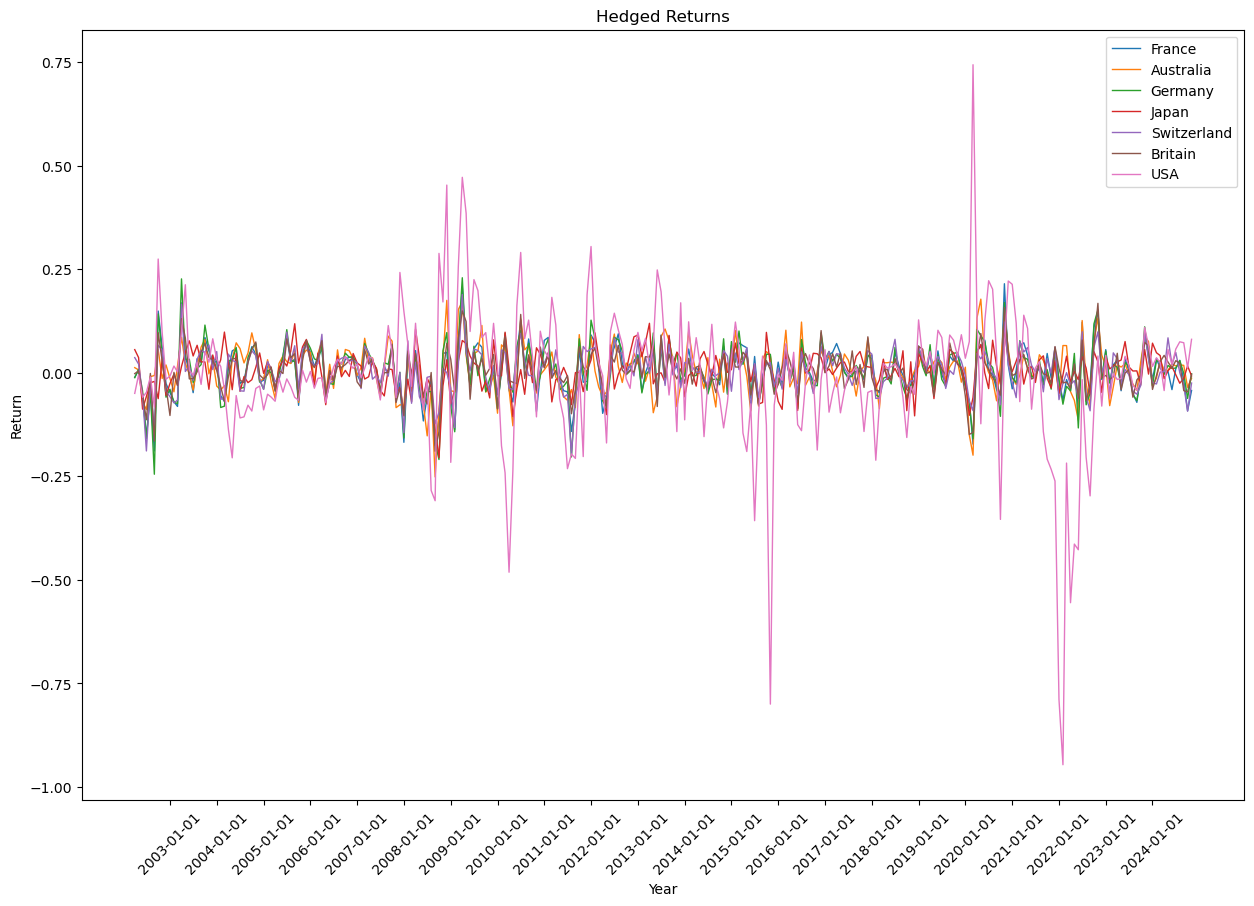

In [435]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 10))  # Adjust figure size to be slightly smaller

# Convert 'date' column to datetime format for better plotting
hedged_returns['date'] = pd.to_datetime(hedged_returns['date'])

# Plotting each country's returns
for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns['date'], hedged_returns[country], linestyle='-', linewidth=1, label=country)

# Setting x-axis ticks to show unique years and inclining dates by 45 degrees
ax.set_xticks(pd.date_range(start=hedged_returns['date'].min(), end=hedged_returns['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Return')
ax.legend()
plt.show()
